# Laboratorio 9: AdaBoost y contenedores

**Duración:** 2 horas  
**Formato:** Competencia con contenedores  

---

## Portada del equipo

**Integrantes:**
- Nombre 1 (Usuario GitHub)
- Nombre 2 (Usuario GitHub)
- Nombre 3 (Usuario GitHub)


**Fecha de entrega:**  
__/__/____

## Librerias 

In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import joblib
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Limpieza 

In [48]:
df = pd.read_csv(r"D:./train_set.csv")
print(f"Shape inicial: {df.shape}")
df.head()

Shape inicial: (641, 8)


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,2,male,47.0,0,0,15.0000,S,0
1,3,male,NaN,0,0,8.7125,C,0
2,1,male,NaN,0,0,26.2875,S,1
3,3,male,NaN,1,1,20.5250,S,0
4,3,male,NaN,1,1,15.9000,NaN,1


In [49]:

def preprocess_for_adaboost(csv_path):
    """
    Limpia y prepara el dataset para AdaBoost desde cero.
    Devuelve el DataFrame limpio (df), la matriz X, el vector y_pm, y el scaler.
    """
    df = pd.read_csv(csv_path)
    print(f" Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

    # Detección automática de columnas
    possible_cols = df.columns.str.lower().tolist()
    def has(c): return c in possible_cols

    y_col = None
    for cand in ["survived", "target", "label", "y"]:
        if has(cand):
            y_col = df.columns[df.columns.str.lower() == cand][0]
            break
    if y_col is None:
        y_col = df.columns[-1]

    num_candidates = [c for c in df.columns if df[c].dtype.kind in "if"]
    cat_candidates = [c for c in df.columns if df[c].dtype.kind not in "if" and c != y_col]

    expected_num = [k for k in df.columns if k.lower() in ["age", "fare", "sibsp", "parch"]]
    expected_cat = [k for k in df.columns if k.lower() in ["sex", "embarked", "pclass"]]

    num_features = list(dict.fromkeys(expected_num + [c for c in num_candidates if c != y_col]))
    cat_features = list(dict.fromkeys(expected_cat + [c for c in cat_candidates if c != y_col]))

    X = df.drop(columns=[y_col]).copy()
    y = df[y_col].copy()

    # Outliers
    if "age" in X.columns:
        X["age"] = np.where(X["age"] > 100, np.nan, X["age"])
    if "fare" in X.columns:
        Q1, Q3 = X["fare"].quantile(0.25), X["fare"].quantile(0.75)
        IQR = Q3 - Q1
        upper = Q3 + 1.5 * IQR
        X["fare"] = np.where(X["fare"] > upper, upper, X["fare"])

    # Imputación
    imputer_num = SimpleImputer(strategy="median")
    imputer_cat = SimpleImputer(strategy="most_frequent")

    for col in num_features:
        if col in X.columns:
            X[[col]] = imputer_num.fit_transform(X[[col]])
    for col in cat_features:
        if col in X.columns:
            X[[col]] = imputer_cat.fit_transform(X[[col]])

    # Codificación
    if "sex" in cat_features:
        le_sex = LabelEncoder()
        X["sex"] = le_sex.fit_transform(X["sex"])
    if "embarked" in cat_features:
        X = pd.get_dummies(X, columns=["embarked"], drop_first=True)
    if "pclass" in cat_features and X["pclass"].dtype == object:
        X["pclass"] = LabelEncoder().fit_transform(X["pclass"])

    # Escalado
    scaler = StandardScaler()
    cols_to_scale = [c for c in num_features if c in X.columns]
    X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

    # Conversión de y
    y_unique = sorted(pd.unique(y))
    if set(y_unique) == {0, 1}:
        y_pm = y.replace({0: -1, 1: 1}).to_numpy()
    elif len(y_unique) == 2:
        mapping = {y_unique[0]: -1, y_unique[1]: 1}
        y_pm = y.map(mapping).to_numpy()
    else:
        raise ValueError(" El dataset no es binario. AdaBoost requiere dos clases.")

    # Redefinimos df como el dataset limpio y completo
    df = X.copy()
    df["y_pm"] = y_pm
    print(df.head())

    return df, X, y_pm, scaler


In [50]:
df, X, y_pm, scaler = preprocess_for_adaboost(r"D:./train_set.csv")

 Dataset cargado: 641 filas, 8 columnas
     pclass  sex       age     sibsp     parch      fare  embarked_Q  \
0 -0.380214    1  1.173577 -0.472826 -0.447791 -0.428725       False   
1  0.820363    1 -0.082379 -0.472826 -0.447791 -0.743903       False   
2 -1.580790    1 -0.082379 -0.472826 -0.447791  0.137091       False   
3  0.820363    1 -0.082379  0.565125  0.748184 -0.151770       False   
4  0.820363    1 -0.082379  0.565125  0.748184 -0.383610       False   

   embarked_S  y_pm  
0        True    -1  
1       False    -1  
2        True     1  
3        True    -1  
4        True     1  


In [51]:
joblib.dump(scaler, "preprocessor.pkl")

['preprocessor.pkl']

## Elemento 1 - Implementación desde cero de AdaBoost

In [52]:
class SimpleAdaBoost:
    def __init__(self, base_estimator=None, n_estimators=50):
        self.n_estimators = n_estimators
        self.base_estimator = base_estimator or DecisionTreeClassifier(max_depth=1)
        self.alphas = []
        self.models = []
        self.errors = [] 

    def fit(self, X, y):
        n_samples = X.shape[0]
        D = np.ones(n_samples) / n_samples

        for t in range(self.n_estimators):
            h_t = self.base_estimator.__class__(**self.base_estimator.get_params())
            h_t.fit(X, y, sample_weight=D)

            y_pred = h_t.predict(X)
            err_t = np.sum(D * (y_pred != y)) / np.sum(D)
            err_t = max(err_t, 1e-10)  # evita dividir entre cero

            alpha_t = 0.5 * np.log((1 - err_t) / err_t)

            # Actualización de pesos
            D *= np.exp(-alpha_t * y * y_pred)
            D /= np.sum(D)

            # Guardar resultados
            self.models.append(h_t)
            self.alphas.append(alpha_t)
            self.errors.append(err_t)  

            print(f"Iter {t+1}/{self.n_estimators}: ε={err_t:.4f}, α={alpha_t:.4f}")

        return self

    def predict(self, X, return_scores=False):
        pred = np.zeros(X.shape[0])
        for alpha, model in zip(self.alphas, self.models):
            pred += alpha * model.predict(X)

        if return_scores:
            return pred

        y_pred = np.sign(pred)
        y_pred[y_pred == 0] = 1
        y_pred = (y_pred + 1) / 2
        return y_pred.astype(int)


In [53]:
ada = SimpleAdaBoost(n_estimators=20)
ada.fit(X, y_pm)
y_pred = ada.predict(X)

Iter 1/20: ε=0.2122, α=0.6560
Iter 2/20: ε=0.3323, α=0.3488
Iter 3/20: ε=0.4620, α=0.0762
Iter 4/20: ε=0.4779, α=0.0442
Iter 5/20: ε=0.4788, α=0.0423
Iter 6/20: ε=0.4555, α=0.0892
Iter 7/20: ε=0.4488, α=0.1027
Iter 8/20: ε=0.4675, α=0.0652
Iter 9/20: ε=0.4330, α=0.1349
Iter 10/20: ε=0.4603, α=0.0796
Iter 11/20: ε=0.4643, α=0.0715
Iter 12/20: ε=0.4738, α=0.0524
Iter 13/20: ε=0.4714, α=0.0573
Iter 14/20: ε=0.4731, α=0.0538
Iter 15/20: ε=0.4764, α=0.0473
Iter 16/20: ε=0.4617, α=0.0767
Iter 17/20: ε=0.4507, α=0.0990
Iter 18/20: ε=0.4600, α=0.0801
Iter 19/20: ε=0.4542, α=0.0919
Iter 20/20: ε=0.4792, α=0.0416


### Elemento 1 - Preguntas teóricas

• ¿Qué significa que un clasificador sea “débil” dentro del contexto de AdaBoost?

Un clasificador débil es aquel cuyo desempeño es apenas mejor que el azar, es decir, su error cumple $ \varepsilon_t < 0.5 $.  
En AdaBoost, estos clasificadores (por ejemplo, árboles de decisión de profundidad 1) se combinan secuencialmente con pesos

$$
\alpha_t = \frac{1}{2}\ln\!\left(\frac{1 - \varepsilon_t}{\varepsilon_t}\right)
$$

para formar un modelo fuerte con menor error global.


• ¿Por qué los ejemplos mal clasificados ganan mayor peso en las iteraciones siguientes?

Porque AdaBoost enfoca el aprendizaje en los errores previos.  
Después de cada iteración, los pesos se actualizan según

$$
D_{t+1}(i) = \frac{D_t(i)\, e^{-\alpha_t y_i h_t(x_i)}}{Z_t},
$$

de modo que los ejemplos mal clasificados ($y_i \neq h_t(x_i)$) aumentan su peso $D_{t+1}(i)$, teniendo más influencia en el siguiente clasificador.

• ¿Qué efecto tiene aumentar el número de clasificadores débiles sobre el sesgo y la varianza?

Al incrementar los clasificadores:
- El sesgo disminuye, ya que el ensamble aprende patrones más complejos.  
- La varianza aumenta, porque el modelo se vuelve más sensible a pequeñas variaciones o ruido.  

Por tanto, un número excesivo de clasificadores puede provocar sobreajuste.

• ¿Por qué AdaBoost es sensible al ruido y a los outliers?

Porque los ejemplos mal clasificados (incluyendo los ruidosos) reciben mayor peso en las siguientes iteraciones.  
El modelo intenta ajustarse a esos datos erróneos, lo que genera fronteras de decisión inestables y pérdida de generalización.

## Elemento 2 - Comparativa con scikit-learn

 Dataset cargado: 641 filas, 8 columnas
     pclass  sex       age     sibsp     parch      fare  embarked_Q  \
0 -0.380214    1  1.173577 -0.472826 -0.447791 -0.428725       False   
1  0.820363    1 -0.082379 -0.472826 -0.447791 -0.743903       False   
2 -1.580790    1 -0.082379 -0.472826 -0.447791  0.137091       False   
3  0.820363    1 -0.082379  0.565125  0.748184 -0.151770       False   
4  0.820363    1 -0.082379  0.565125  0.748184 -0.383610       False   

   embarked_S  y_pm  
0        True    -1  
1       False    -1  
2        True     1  
3        True    -1  
4        True     1  
Iter 1/100: ε=0.2143, α=0.6496
Iter 2/100: ε=0.3153, α=0.3876
Iter 3/100: ε=0.4741, α=0.0518
Iter 4/100: ε=0.4589, α=0.0824
Iter 5/100: ε=0.4581, α=0.0841
Iter 6/100: ε=0.4182, α=0.1650
Iter 7/100: ε=0.4843, α=0.0314
Iter 8/100: ε=0.4594, α=0.0814
Iter 9/100: ε=0.4635, α=0.0731
Iter 10/100: ε=0.4717, α=0.0566
Iter 11/100: ε=0.4732, α=0.0536
Iter 12/100: ε=0.4746, α=0.0509
Iter 13/100: ε=0.468

c:\Users\ENRIQUE\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\ENRIQUE\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\ENRIQUE\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\ENRIQUE\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the defa

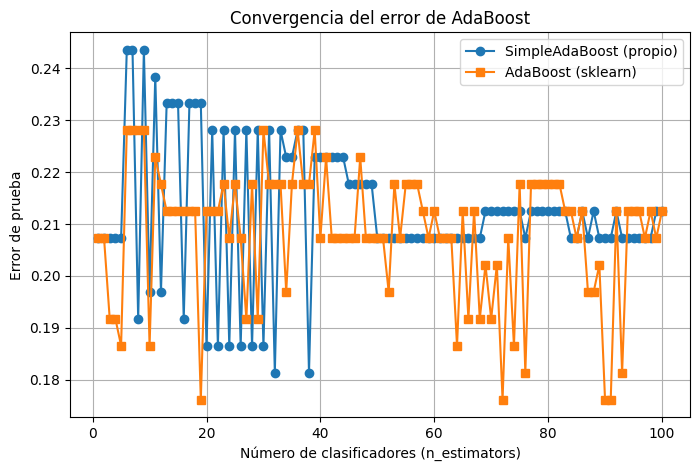

In [54]:

df, X, y_pm, scaler = preprocess_for_adaboost(r"D:./train_set.csv")

# Convertir a 0/1 (sklearn usa 0/1, no -1/+1)
y_bin = (y_pm + 1) // 2

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

#  propio vs sklearn

n_estimators = 100
base = DecisionTreeClassifier(max_depth=1, random_state=42)

# Nuestra implementación
ada_simple = SimpleAdaBoost(base_estimator=base, n_estimators=n_estimators)
ada_simple.fit(X_train, 2*y_train - 1)  # el nuestro si trabaja con {-1,+1}

# sklearn
ada_sklearn = AdaBoostClassifier(
    estimator=base,
    n_estimators=n_estimators,
    learning_rate=1.0,
    algorithm="SAMME",
    random_state=42
)
ada_sklearn.fit(X_train, y_train)

#  Predicciones y métricas

# Nuestro modelo: convertir salida {-1,+1} → {0,1}
y_pred_simple = ada_simple.predict(X_test)

# sklearn
y_pred_sklearn = ada_sklearn.predict(X_test)

# Métricas comparativas
def evaluar(y_true, y_pred, nombre):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"\n🔹 {nombre}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    return acc, prec, rec, f1

metrics_simple = evaluar(y_test, y_pred_simple, "SimpleAdaBoost (Propio)")
metrics_sklearn = evaluar(y_test, y_pred_sklearn, "AdaBoost (sklearn)")


#  Convergencia del error por número de clasificadores

T_values = range(1, n_estimators + 1)
errors_simple, errors_sklearn = [], []

for T in T_values:
    # Error en nuestro modelo hasta t clasificadores
    y_pred_T = np.sign(sum(
        a * m.predict(X_test) for a, m in zip(ada_simple.alphas[:T], ada_simple.models[:T])
    ))
    y_pred_T = (y_pred_T + 1) / 2
    err_T_simple = 1 - accuracy_score(y_test, y_pred_T)
    errors_simple.append(err_T_simple)

    # Error sklearn hasta t clasificadores
    ada_tmp = AdaBoostClassifier(estimator=base, n_estimators=T, random_state=42)
    ada_tmp.fit(X_train, y_train)
    y_pred_tmp = ada_tmp.predict(X_test)
    err_T_sklearn = 1 - accuracy_score(y_test, y_pred_tmp)
    errors_sklearn.append(err_T_sklearn)


#  Gráfico de convergencia del error
plt.figure(figsize=(8,5))
plt.plot(T_values, errors_simple, marker='o', label='SimpleAdaBoost (propio)')
plt.plot(T_values, errors_sklearn, marker='s', label='AdaBoost (sklearn)')
plt.xlabel("Número de clasificadores (n_estimators)")
plt.ylabel("Error de prueba")
plt.title("Convergencia del error de AdaBoost")
plt.legend()
plt.grid(True)
plt.show()

#  Fronteras de decisión (solo para 2 variables)

if X.shape[1] == 2:
    from matplotlib.colors import ListedColormap

    def plot_decision_boundary(model, X, y, title):
        x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
        y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        plt.figure(figsize=(6, 5))
        plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA','#AAFFAA']))
        plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=ListedColormap(['#FF0000','#00FF00']), edgecolor='k')
        plt.title(title)
        plt.show()

    plot_decision_boundary(ada_simple, X_test, y_test, "Frontera de decisión - SimpleAdaBoost")
    plot_decision_boundary(ada_sklearn, X_test, y_test, "Frontera de decisión - sklearn AdaBoost")


La comparación nos dice que la implementación propia de AdaBoost nos da la convergencia del error observada en el modelo de referencia de scikit-learn.
Aunque la versión manual presenta mayor variacion entre iteraciones, ambas alcanzan errores similares tras muchos de clasificadores.
El modelo de sklearn es más estable pues de seguro tiene optimizaciones numéricas internas (SAMME.R), mientras que el SimpleAdaBoost podemos ver mejor el comportamiento teórico del algoritmo.

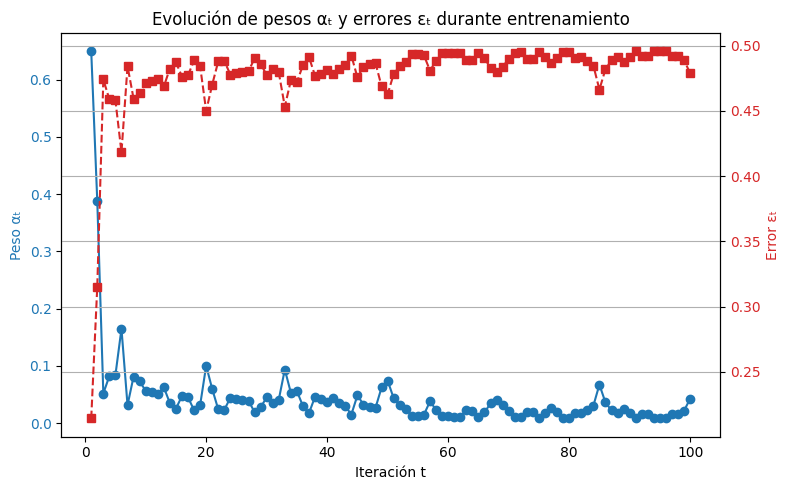

In [55]:
T = range(1, len(ada_simple.alphas) + 1)

fig, ax1 = plt.subplots(figsize=(8,5))

color1 = 'tab:blue'
ax1.set_xlabel("Iteración t")
ax1.set_ylabel("Peso αₜ", color=color1)
ax1.plot(T, ada_simple.alphas, marker='o', color=color1, label="αₜ (peso del clasificador débil)")
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel("Error εₜ", color=color2)
ax2.plot(T, ada_simple.errors, marker='s', linestyle='--', color=color2, label="εₜ (error ponderado)")
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Evolución de pesos αₜ y errores εₜ durante entrenamiento")
fig.tight_layout()
plt.grid(True)
plt.show()

### Elemento 2 - Preguntas teóricas

• ¿Qué ventajas ofrece el AdaBoost implementado en scikit-learn frente a la versión básica?

La implementación de `scikit-learn`:
- Utiliza el algoritmo SAMME.R, que suaviza el cálculo de $\alpha_t$ mediante funciones exponenciales continuas.  
- Incluye tolerancias numéricas y regularización que evitan inestabilidad o desbordamientos.  
- Es más eficiente y robusta ante ruido o clases desbalanceadas.

• ¿Por qué el número de clasificadores afecta la estabilidad del modelo?

Cada clasificador contribuye a la suma ponderada

$$
F(x) = \sum_t \alpha_t h_t(x),
$$

que determina la frontera de decisión.  
Con pocos clasificadores hay alto sesgo; con demasiados, el modelo oscila y sobreajusta, reduciendo su estabilidad.

• ¿Qué sucede si algunos pesos $D_t(i)$ tienden a cero o se concentran en pocos ejemplos?

Si la mayoría de los $D_t(i)$ se vuelven muy pequeños, solo unos pocos ejemplos dominan el aprendizaje.  
Esto genera sobreajuste local y pérdida de representatividad, ya que el modelo se enfoca en casos aislados y deja de generalizar correctamente.

• ¿Cómo se puede evitar el sobreajuste en AdaBoost?


- Limitar el número de iteraciones $T$ .  
- Usar clasificadores débiles más simples (por ejemplo, `max_depth = 1`).  
- Regularizar los pesos $\alpha_t$ o truncar valores extremos.  
- Validar el modelo en un conjunto de prueba y detener el entrenamiento cuando el error deje de mejorar.


## Elemento 3 - API, contenedor Docker y automatización con Makefile

### Elemento 3 - Preguntas teóricas

## Conclusiones de la práctica